##### Link to dataset: https://data.cityofnewyork.us/Housing-Development/Affordable-Housing-Production-by-Building/hg8x-zxpr/about_data

##### Project Goals: 
##### - Perform a thorough analysis of affordable housing created under the Housing New York plan (1/1/2014 – 12/31/2021) or the Housing Our Neighbors: A Blueprint for Housing & Homelessness plan (1/1/2022 – present)
##### - Borough Distribution: how many were created in each borough?
##### - Accessibility for families of various sizes: what is the count of units for each bedroom amount (studio - 6+ bedrooms)?
##### - Which housing plan developed more affordable housing? Housing New York plan (de Blasio) or the Housing Our Neighbors: A Blueprint for Housing & Homelessness plan (Adams)?
##### - Distribution of construction type? Were more efforts put into constructing new buildings or preserving already created buildings?
##### - Unit distribution among AMI: How many units were created for each AMI bracket? Does the final count match the numbers projected in the housing plan proposal? 

## Import pandas and numpy

In [1]:
#import pandas and numpy to analyze the data
import pandas as pd
import numpy as np

#import csv and pprint to look at raw data 
import csv 
from pprint import pprint

## Load dataset

In [2]:
#read csv into a df using pandas read_csv
df = pd.read_csv("C:/Users/arime/Downloads/Projects/NY Affordable Housing DATA 506L Project/Affordable_Housing_Production.csv")
df.head(5) #view first 5 rows of the df to ensure it loaded correctly

,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Number,Street,Borough,Postcode,BBL,...,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,Counted Rental Units,Counted Homeownership Units,All Counted Units,Total Units
0,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,88524.0,390,JACKSON AVENUE,Bronx,10454.0,2.025730e+09,...,26.0,10.0,6.0,NaN,NaN,NaN,42.0,NaN,42.0,42
1,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,110912.0,720,ST MARYS STREET,Bronx,10454.0,2.025730e+09,...,25.0,16.0,NaN,NaN,NaN,NaN,42.0,NaN,42.0,42
2,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,111383.0,1070,REV JAMES POLITE AVENUE,Bronx,10459.0,2.026910e+09,...,11.0,9.0,1.0,NaN,NaN,NaN,22.0,NaN,22.0,22
3,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,115143.0,581,TIMPSON PLACE,Bronx,10455.0,2.026030e+09,...,39.0,33.0,NaN,NaN,NaN,NaN,72.0,NaN,72.0,72
4,71239,MBD.MBD CLUSTER3.NR REHAB,06/30/2025,NaN,116845.0,1805,UNIVERSITY AVENUE,Bronx,10453.0,2.028790e+09,...,11.0,1.0,NaN,NaN,NaN,NaN,25.0,NaN,25.0,25


## Shape of original df

In [3]:
df.shape #8,605 rows and 41 columns 

(8605, 41)

## Update dataframe to only keep relevant columns (will make next steps more readable)

In [4]:
df = df.drop(columns= ['Number','Street','Postcode','BBL','BIN','Community Board','Council District','Census Tract',
                       'NTA - Neighborhood Tabulation Area','Latitude (Internal)','Longitude (Internal)','Prevailing Wage Status',
                      'Counted Rental Units','Counted Homeownership Units'])
df.head() #check to see if columns were dropped

,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Borough,Latitude,Longitude,Building Completion Date,Reporting Construction Type,...,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
0,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,88524.0,Bronx,40.809134,-73.910554,NaN,Preservation,...,NaN,NaN,26.0,10.0,6.0,NaN,NaN,NaN,42.0,42
1,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,110912.0,Bronx,40.808755,-73.910479,NaN,Preservation,...,NaN,1.0,25.0,16.0,NaN,NaN,NaN,NaN,42.0,42
2,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,111383.0,Bronx,40.825362,-73.898829,NaN,Preservation,...,NaN,1.0,11.0,9.0,1.0,NaN,NaN,NaN,22.0,22
3,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,115143.0,Bronx,40.811782,-73.902498,NaN,Preservation,...,NaN,NaN,39.0,33.0,NaN,NaN,NaN,NaN,72.0,72
4,71239,MBD.MBD CLUSTER3.NR REHAB,06/30/2025,NaN,116845.0,Bronx,40.850665,-73.915259,NaN,Preservation,...,NaN,13.0,11.0,1.0,NaN,NaN,NaN,NaN,25.0,25


## Updated df shape

In [5]:
df.shape #8,605 rows and 27 columns after dropping less relevant columns

(8605, 27)

#### Project ID: Unique numeric identifier assigned to each project
#### Project Name: Project name assigned to the project 
#### Project Group: A broader program category for a project that is based on the project's primary program
#### Project Start Date: Date of the project loan or agreement closing
#### Project Completion Date: The date that the last building in the project was completed
#### Building ID: Unique numeric identifier assigned to each building
#### Borough: Borough where the building is located
#### Latitude: Specify the latitude location of the property on the earth's surface. Coordinates provided are an estimate of the location based on the street segment and address range.
#### Longitude: Specify the longitude location of the property on the earth's surface. Coordinates provided are an estimate of the location based on the street segment and address range.
#### Building Completion Date: The date the building was completed
#### Reporting Construction Type: Indicates whether the building is categorized as 'new construction' or 'preservation' in HPD housing production statistics
#### Extended Affordability Only: Indicates whether the project is considered to be Extended Affordability
#### Extremely Low-Income Units: Units with rents that are affordable to households earning 0-30% of the area median income (AMI).
#### Very Low-Income Units: Units with rents that are affordable to households earning 31-50% of the area median income (AMI).
#### Low-Income Units: Units with rents that are affordable to households earning 51-80% of the area median income (AMI).
#### Moderate Income Units: Units with rents that are affordable to households earning 81-120% of the area median income (AMI).
#### Middle Income Units: Units with rents that are affordable to households earning 121-165% of the area median income (AMI).
#### Other Income Units: Units reserved for building superintendents 
#### Studio Units: Units with 0 bedrooms 
#### 1-BR Units: Units with 1 bedroom
#### 2-BR Units: Units with 2 bedrooms
#### 3-BR Units: Units with 3 bedrooms
#### 4-BR Units: Units with 4 bedrooms
#### 5-BR Units: Units with 5 bedrooms
#### 6-BR+ Units: Units with 6 bedrooms or more
#### Unknown-BR Units: Units with an unknown number of bedrooms
#### All Counted Units: Indicates the total number of affordable, regulated units counted towards a housing plan that are in the building
#### Total Units: Indicates the total number of units, affordable and market rate, in each building

## Check data types

In [10]:
#check the data types of the different columns to see if they are correct
df.dtypes 

Project ID                       int64
Project Name                    object
Project Start Date              object
Project Completion Date         object
Building ID                    float64
Borough                         object
Latitude                       float64
Longitude                      float64
Building Completion Date        object
Reporting Construction Type     object
Extended Affordability Only     object
Extremely Low Income Units     float64
Very Low Income Units          float64
Low Income Units               float64
Moderate Income Units          float64
Middle Income Units            float64
Other Income Units             float64
Studio Units                   float64
1-BR Units                     float64
2-BR Units                     float64
3-BR Units                     float64
4-BR Units                     float64
5-BR Units                     float64
6-BR+ Units                    float64
Unknown-BR Units               float64
All Counted Units        

#### Almost all of the data types seem accurate except for a few: Project Start and Completion Date, and Building Completion Date are recorded as objects. Pandas appears to have read dates in this df as an object, something to look into. 

In [11]:
#list of the columns i want to inspect 
df[['Project Start Date','Project Completion Date','Building Completion Date']] 

,Project Start Date,Project Completion Date,Building Completion Date
0,06/30/2025,NaN,NaN
1,06/30/2025,NaN,NaN
2,06/30/2025,NaN,NaN
3,06/30/2025,NaN,NaN
4,06/30/2025,NaN,NaN
...,...,...,...
8600,01/14/2014,01/14/2014,01/14/2014
8601,01/10/2014,01/10/2014,01/10/2014
8602,01/10/2014,01/10/2014,01/10/2014
8603,01/07/2014,01/07/2014,01/07/2014


#### Things to note: 
##### Project Start Date, Project Completion Date, and Building Completion Date are all treated as strings in mm/dd/yyyy format. These dates will be important for my analysis, I will have to change them to datetime format later

## Look for bad data - Null values

In [12]:
df.isnull().sum() #get the count of null values for each column 

Project ID                        0
Project Name                      0
Project Start Date                0
Project Completion Date        1865
Building ID                    1715
Borough                           0
Latitude                       1718
Longitude                      1718
Building Completion Date       1714
Reporting Construction Type       0
Extended Affordability Only       0
Extremely Low Income Units     6757
Very Low Income Units          5557
Low Income Units               3669
Moderate Income Units          7138
Middle Income Units            6144
Other Income Units             7387
Studio Units                   5766
1-BR Units                     3122
2-BR Units                     3172
3-BR Units                     5454
4-BR Units                     8073
5-BR Units                     8542
6-BR+ Units                    8581
Unknown-BR Units               7972
All Counted Units                28
Total Units                       0
dtype: int64

## Findings - Null Values
##### - There are null values in every column except for Project ID, Project Name, Project Start Date, Borough, Reporting Construction Type, Extended Affordability, and Total Units
##### - This is good because every entry has a project ID, project name, start date, borough, construction type, and extended affordability that can be used to track it. This allows me to complete my goals of analyzing borough and construction type distributions as well as which housing plan developed more affordable housing (seeing whether the project start date falls in the timeframe of which plan). 
##### - Lots of null values in other columns are expected. Null completion dates represent ongoing projects or buildings that have not been finished yet. 
##### - Null values in Building ID is inconvenient, but I believe projects will be easier to track using project ID
##### - Null latitude and longitude values are also inconvenient but will not affect this portion of the project (I am interested in mapping affordable housing locations as a personal project extension)
##### - There are expected to be null values in each of the AMI bracket units (low income, moderate income, middle income, etc) as most projects did not create units for every single AMI bracket 
##### - Similarly, there are expected to be null values in the different bedroom counts for the same reason. Most projects did not create units containing every single bedroom amount option

## Inspect values for categorical columns

In [13]:
#create df of the categorical columns, done manually to inspect the columns that will be relevant for my analysis 
categorical_columns = df[['Project Name','Borough','Reporting Construction Type','Extended Affordability Only',
    'Project Start Date','Project Completion Date','Building Completion Date']]

#loop through every column of categorical_columns df, print their unique values and the counts of them
for column in categorical_columns: 
    print(f"Column: {column}")
    print(categorical_columns[column].value_counts())
    print("-" * 30)

Column: Project Name
Project Name
CONFIDENTIAL                                         1715
EASTCHESTER HEIGHTS HDFC.HPO.FY25                     114
Nehemiah Spring Creek Homes at Gateway Estates 4A      83
COOP CITY.HRP.FY20                                     79
JOE CENTRAL BROOKLYN LLC.YR15.FY19                     79
                                                     ... 
Margarita Santos Apartments HDFC                        1
Logan Plaza                                             1
CAMBA. 331 Saratoga Ave. Bergen Saratoga                1
2120 Mapes Avenue HDFC                                  1
1790 Clinton Avenue                                     1
Name: count, Length: 3538, dtype: int64
------------------------------
Column: Borough
Borough
Brooklyn         3395
Bronx            2306
Manhattan        1331
Queens           1181
Staten Island     392
Name: count, dtype: int64
------------------------------
Column: Reporting Construction Type
Reporting Construction Type
Pr

## Findings - Categorical columns:
##### - Project Name: significant amount of project names are confidential. Top three project names are: EASTCHESTER HEIGHTS HDFC.HPO.FY25 (114), Nehemiah Spring Creek Homes at Gateway Estates 4A (83), and COOP CITY.HRP.FY20 (79)
##### - Borough: affordable housing built in all 5 boroughs. Brooklyn (3395), Bronx (2306), Manhattan (1331), Queens (1181), Staten Island (392)
##### - Reporting Construction Type: almost equal amount of preservation (4390) and new construction (4215)
##### - Extended Affordability Only: mostly not extended affordability (7330) rather than yes (1275)
##### - Project Start Date: lots of various starting dates, but there are numerous projects that start on the same date. Top three starting dates: 06/30/2021 (146), 12/19/2024 (125), 06/20/2019 (107)
##### - Project Completion Date: lots of various completion dates, but there are numerous projects that are completed on the same date. Top three completion dates: 06/20/2019 (103), 06/25/2024 (87), 05/28/2019 (84)
##### - Building Completion Date: lots of various completion dates, but there are numerous buildings that are completed on the same date. Top three completion dates: 06/20/2019 (103), 12/31/2017 (73), 06/26/2017 (70)

## Inspecting numerical columns:

In [14]:
#create df of the numerical columns, done manually to inspect the columns that will be relevant for my analysis 
numerical_columns = df[['Extremely Low Income Units','Very Low Income Units','Low Income Units','Moderate Income Units',
                        'Middle Income Units','Other Income Units','Studio Units','1-BR Units','2-BR Units','3-BR Units',
                        '4-BR Units','5-BR Units','6-BR+ Units','Unknown-BR Units', 'All Counted Units','Total Units']]

#obtain summary statistics for each of these columns
numerical_columns.describe()

,Extremely Low Income Units,Very Low Income Units,Low Income Units,Moderate Income Units,Middle Income Units,Other Income Units,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
count,1848.00000,3048.000000,4936.000000,1467.000000,2461.000000,1218.000000,2839.000000,5483.000000,5433.000000,3151.000000,532.000000,63.000000,24.00000,633.000000,8577.000000,8605.000000
mean,27.63474,26.073163,20.252026,12.310838,16.670866,1.027094,17.609722,19.046507,17.777839,10.523009,5.137218,2.746032,3.75000,5.805687,33.909525,46.700058
std,43.23779,50.071025,41.794461,31.895317,34.429588,0.275105,33.575216,31.192185,29.800153,17.621614,8.477841,3.537669,7.51954,35.639215,66.161293,93.370691
min,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
25%,2.00000,3.000000,1.000000,1.000000,3.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2.000000,3.000000
50%,8.00000,7.000000,5.000000,3.000000,6.000000,1.000000,5.000000,6.000000,7.000000,4.000000,2.000000,1.000000,1.00000,1.000000,8.000000,12.000000
75%,36.00000,22.000000,20.000000,9.000000,15.000000,1.000000,19.000000,21.000000,18.000000,11.000000,6.000000,3.500000,2.25000,2.000000,31.000000,44.000000
max,429.00000,396.000000,536.000000,454.000000,448.000000,9.000000,569.000000,312.000000,305.000000,193.000000,115.000000,23.000000,28.00000,536.000000,917.000000,1320.000000


In [15]:
#create df containing information of units created for each AMI bracket 
units_ami = df[['Extremely Low Income Units','Very Low Income Units','Low Income Units','Moderate Income Units',
    'Middle Income Units','Other Income Units']]

#add the count of each column to get the total number of units 
total_units_ami = units_ami.count().sum()

#divide count of each AMI unit by the total number of units to get the percentage of units created for each AMI bracket 
print('Percentage of units created for each AMI bracket:\n')
for column in units_ami: #for loop to iterate through each column in units_ami
    print(f'{column}: {(units_ami[column].count() / total_units_ami) * 100:.2f}%') #multiply by 100 to get percentage, to the 2nd decimal and add %

Percentage of units created for each AMI bracket:

Extremely Low Income Units: 12.34%
Very Low Income Units: 20.35%
Low Income Units: 32.96%
Moderate Income Units: 9.79%
Middle Income Units: 16.43%
Other Income Units: 8.13%


In [16]:
#create df containing information of bedroom units
units_bedrooms = df[['Studio Units','1-BR Units','2-BR Units','3-BR Units','4-BR Units','5-BR Units','6-BR+ Units','Unknown-BR Units']]

#add the count of each column to get the total number of units 
total_units_bedrooms = units_bedrooms.count().sum()

#divide count of each bedroom unit by the total number of units to get the percentage of units for each number of bedrooms
print('Percentage of units by number of bedrooms:\n')
for column in units_bedrooms: #for loop to iterate through each column in units_bedrooms
    print(f'{column}: {(units_bedrooms[column].count() / total_units_bedrooms) * 100:.2f}%') #multiply by 100 to get percentage, 
    #to the 2nd decimal and add %

Percentage of units by number of bedrooms:

Studio Units: 15.63%
1-BR Units: 30.20%
2-BR Units: 29.92%
3-BR Units: 17.35%
4-BR Units: 2.93%
5-BR Units: 0.35%
6-BR+ Units: 0.13%
Unknown-BR Units: 3.49%


## Findings - Numerical columns
#####
##### Distribution of units among AMI brackets:
##### - Extremely Low Income Units: 12.34%
##### - Very Low Income Units: 20.35%
##### - Low Income Units: 32.96%
##### - Moderate Income Units: 9.79%
##### - Middle Income Units: 16.43%
##### - Other Income Units: 8.13%
#####
##### - There is a decent spread of units among the AMI brackets. The Extremely Low Income AMI bracket could be higher, given that this bracket is most likely the most in need for affordable housing. Moving forward, I would like to explore the relationship between AMI unit distribution and NYC borough to see if there was a particular need for units within a certain AMI bracket in certain boroughs. 
#####  
##### Distribution of number of bedrooms in units 
##### - Studio Units: 15.63%
##### - 1-BR Units: 30.20%
##### - 2-BR Units: 29.92%
##### - 3-BR Units: 17.35%
##### - 4-BR Units: 2.93%
##### - 5-BR Units: 0.35%
##### - 6-BR+ Units: 0.13%
##### Unknown-BR Units: 3.49%
#####
##### - Most units range from studio to 3-BR units. There are much, much less units that are 4 bedrooms and larger. This affects large families who are in need of units with lots of bedrooms. This highlights significant accessibility issues in the units created in both affordable housing plans

##### To determine which housing plan developed more affordable housing and the average length of time to complete projects, I will have to wait until I do data cleaning on date columns. 

## Future Goals for Project - 
#### - Explore relationship between AMI bracket and borough
#### - Analyze project start/completion dates to see which plan they belong to and average time to complete
#### - Which boroughs had new construction vs preservation 

# Deliverable 3 - Data Cleaning and Transformation

## Recheck missing values

In [17]:
#recheck columns that have missing values 
df.isnull().sum() 

Project ID                        0
Project Name                      0
Project Start Date                0
Project Completion Date        1865
Building ID                    1715
Borough                           0
Latitude                       1718
Longitude                      1718
Building Completion Date       1714
Reporting Construction Type       0
Extended Affordability Only       0
Extremely Low Income Units     6757
Very Low Income Units          5557
Low Income Units               3669
Moderate Income Units          7138
Middle Income Units            6144
Other Income Units             7387
Studio Units                   5766
1-BR Units                     3122
2-BR Units                     3172
3-BR Units                     5454
4-BR Units                     8073
5-BR Units                     8542
6-BR+ Units                    8581
Unknown-BR Units               7972
All Counted Units                28
Total Units                       0
dtype: int64

#### Columns to look at:
#### - Project and Building Completion Date
#### - Building ID
#### - Each AMI Unit bracket (Extremely Low Income to Other Income)
#### - Each number of bedroom unit (Studio to Unknown-BR)
#### - All Counted Units
#### - Although Longitude and Latitude have missing values, they won't be used for this project so I will leave them be for now

## Project Completion Date and Building Completion Date 
#### Null values in Project Completion Date and Building Completion Date are important because they tell which projects/buildings are still in development. For now, I will leave these columns as they are, and when I change Project Start Date, Project Completion Date, and Building Completion date to datetime format, I will change NaN values to NaT (null for datetime values)

## Building ID
#### Building ID is a unique identifer for the building making up each row, but it has 1715 missing values. These numbers cannot be made up because they are unique to each building and cannot be traced with longitude and latitude values (NaN as well) or Project Name (most are confidential). Multiple buildings can be attached to one Project ID, so I cannot use that as the identifier either. So, I will create a new column that will serve as the unique identifer for each row and leave NaN values in Building ID as NaN. 

In [18]:
#there are 1715 rows with NaN values for Building ID
df[df['Building ID'].isna()]

,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Borough,Latitude,Longitude,Building Completion Date,Reporting Construction Type,...,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
18,76514,CONFIDENTIAL,06/30/2025,NaN,NaN,Brooklyn,NaN,NaN,NaN,Preservation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,3
22,77088,CONFIDENTIAL,06/30/2025,06/30/2025,NaN,Staten Island,NaN,NaN,06/30/2025,New Construction,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1
23,77089,CONFIDENTIAL,06/30/2025,06/30/2025,NaN,Bronx,NaN,NaN,06/30/2025,New Construction,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,1
24,77096,CONFIDENTIAL,06/30/2025,NaN,NaN,Queens,NaN,NaN,NaN,Preservation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1
25,77176,CONFIDENTIAL,06/30/2025,NaN,NaN,Brooklyn,NaN,NaN,NaN,Preservation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8600,55697,CONFIDENTIAL,01/14/2014,01/14/2014,NaN,Brooklyn,NaN,NaN,01/14/2014,Preservation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1
8601,55773,CONFIDENTIAL,01/10/2014,01/10/2014,NaN,Staten Island,NaN,NaN,01/10/2014,Preservation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1
8602,57341,CONFIDENTIAL,01/10/2014,01/10/2014,NaN,Staten Island,NaN,NaN,01/10/2014,New Construction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1
8603,55647,CONFIDENTIAL,01/07/2014,01/07/2014,NaN,Brooklyn,NaN,NaN,01/07/2014,Preservation,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1


In [19]:
#there are multiple rows under 1 Project ID number so it cannot be the unique identifier for each row 
df['Project ID'].value_counts()

Project ID
75173    114
53017     83
68530     79
66670     79
53157     75
        ... 
55697      1
55773      1
57341      1
55647      1
73540      1
Name: count, Length: 5252, dtype: int64

In [20]:
#create new column Unique ID that will serve as identifier for each row
df['Unique ID'] = range(1, len(df) + 1)

In [21]:
#make Unique ID the first column in df
col = df.pop('Unique ID')
df.insert(0, 'Unique ID', col)

In [22]:
#check to see if it worked: it did 
df.head()

,Unique ID,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Borough,Latitude,Longitude,Building Completion Date,...,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
0,1,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,88524.0,Bronx,40.809134,-73.910554,NaN,...,NaN,NaN,26.0,10.0,6.0,NaN,NaN,NaN,42.0,42
1,2,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,110912.0,Bronx,40.808755,-73.910479,NaN,...,NaN,1.0,25.0,16.0,NaN,NaN,NaN,NaN,42.0,42
2,3,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,111383.0,Bronx,40.825362,-73.898829,NaN,...,NaN,1.0,11.0,9.0,1.0,NaN,NaN,NaN,22.0,22
3,4,47863,TIMPSON PLACE HDFC.GHPP.FY25,06/30/2025,NaN,115143.0,Bronx,40.811782,-73.902498,NaN,...,NaN,NaN,39.0,33.0,NaN,NaN,NaN,NaN,72.0,72
4,5,71239,MBD.MBD CLUSTER3.NR REHAB,06/30/2025,NaN,116845.0,Bronx,40.850665,-73.915259,NaN,...,NaN,13.0,11.0,1.0,NaN,NaN,NaN,NaN,25.0,25


## AMI Unit Bracket (Extremely Low Income - Other Income)
#### Looking at the first 10 rows, the sum of all of the AMI units in one row appears to equal the total units for that row. I am going to assume that the NaN values are supposed to represent 0, indicating that no units in that specific AMI bracket was built for the project. So, in each AMI bracket column, I am going to change NaN values to 0. 

In [23]:
#look at first 10 rows of AMI Unit breakdown, see if they are equal to Total Units
df[['Extremely Low Income Units','Very Low Income Units','Low Income Units','Moderate Income Units','Middle Income Units',
    'Other Income Units','Total Units']].head(10)

,Extremely Low Income Units,Very Low Income Units,Low Income Units,Moderate Income Units,Middle Income Units,Other Income Units,Total Units
0,4.0,30.0,8.0,NaN,NaN,NaN,42
1,8.0,33.0,NaN,NaN,NaN,1.0,42
2,3.0,18.0,1.0,NaN,NaN,NaN,22
3,15.0,56.0,NaN,NaN,NaN,1.0,72
4,19.0,1.0,4.0,NaN,NaN,1.0,25
5,16.0,1.0,8.0,NaN,NaN,NaN,25
6,29.0,3.0,8.0,NaN,NaN,NaN,40
7,25.0,3.0,6.0,NaN,NaN,1.0,35
8,35.0,3.0,9.0,NaN,NaN,1.0,48
9,75.0,35.0,NaN,NaN,NaN,1.0,111


In [24]:
#fill all NaN values in each AMI Unit column with 0
df[['Extremely Low Income Units','Very Low Income Units','Low Income Units','Moderate Income Units',
    'Middle Income Units','Other Income Units','Total Units']] = df[['Extremely Low Income Units','Very Low Income Units',
                                                                     'Low Income Units','Moderate Income Units','Middle Income Units',
                                                                     'Other Income Units','Total Units']].fillna(0)

In [25]:
#check to see if changing NaN values to 0 worked: it did 
df[['Extremely Low Income Units','Very Low Income Units','Low Income Units','Moderate Income Units','Middle Income Units',
    'Other Income Units','Total Units']].head(10)

,Extremely Low Income Units,Very Low Income Units,Low Income Units,Moderate Income Units,Middle Income Units,Other Income Units,Total Units
0,4.0,30.0,8.0,0.0,0.0,0.0,42
1,8.0,33.0,0.0,0.0,0.0,1.0,42
2,3.0,18.0,1.0,0.0,0.0,0.0,22
3,15.0,56.0,0.0,0.0,0.0,1.0,72
4,19.0,1.0,4.0,0.0,0.0,1.0,25
5,16.0,1.0,8.0,0.0,0.0,0.0,25
6,29.0,3.0,8.0,0.0,0.0,0.0,40
7,25.0,3.0,6.0,0.0,0.0,1.0,35
8,35.0,3.0,9.0,0.0,0.0,1.0,48
9,75.0,35.0,0.0,0.0,0.0,1.0,111


In [26]:
#now that all columns have a numeric value, check to see if recorded AMI units for each project equals total unit count: 
ami_unit_check = df['Extremely Low Income Units'] + df['Very Low Income Units'] + df['Low Income Units'] + df['Moderate Income Units'] + df['Middle Income Units'] + df['Other Income Units'] == df['Total Units']
ami_unit_check.unique() #not all of recorded AMI units per row equal the total unit count

array([ True, False])

In [27]:
#check how many rows have units unaccounted for: the AMI Unit sum of 2,444 rows do not equal the Total Units count
df[~ami_unit_check][['Extremely Low Income Units','Very Low Income Units','Low Income Units','Moderate Income Units','Middle Income Units',
    'Other Income Units','Total Units']]

,Extremely Low Income Units,Very Low Income Units,Low Income Units,Moderate Income Units,Middle Income Units,Other Income Units,Total Units
11,4.0,1.0,1.0,2.0,3.0,0.0,19
15,7.0,2.0,1.0,2.0,6.0,1.0,21
39,1.0,7.0,8.0,6.0,3.0,0.0,28
40,5.0,5.0,0.0,9.0,7.0,0.0,28
42,1.0,1.0,1.0,4.0,0.0,1.0,9
...,...,...,...,...,...,...,...
8532,0.0,0.0,0.0,67.0,7.0,1.0,99
8543,8.0,0.0,11.0,0.0,3.0,1.0,55
8562,0.0,0.0,2.0,0.0,0.0,0.0,8
8563,0.0,0.0,2.0,0.0,0.0,0.0,8


#### My original assumption was wrong, the sum of AMI Units in 2,444 rows do not equal their Total Units count (out of 8,605 so at least a majority of the units are accounted for). I will calculate the difference to see how many AMI units are unaccounted for

In [28]:
#calculate difference of total units vs ami units accounted for
df.loc[~ami_unit_check, 'ami_Difference'] = (df['Total Units'] - (df['Extremely Low Income Units'] + df['Very Low Income Units'] + 
                                                              df['Low Income Units'] + df['Moderate Income Units'] + df['Middle Income Units'] + 
                                                              df['Other Income Units']))

print(f'Top 5 biggest differences: {df.loc[~ami_unit_check, ['ami_Difference']].sort_values('ami_Difference', ascending=False).head()}')
print(f'Smallest difference {df.loc[~ami_unit_check, ['ami_Difference']].sort_values('ami_Difference', ascending=True).head(1)}')

#Differences range from only 1 unit to up to 900+ (possible entry error). I will look at these large differences when I look at outliers 

Top 5 biggest differences:       ami_Difference
5953          1116.0
2466          1046.0
521            990.0
6677           950.0
8211           940.0
Smallest difference       ami_Difference
2000             1.0


#### Since the Other Income Units column accounts for units reserved for building superintendents, I will create a new column named Unknown Income Units where I will put the ami_Difference values in

In [29]:
#create new column Unknown Income Units and fill with ami_Difference values where there is a difference
df.loc[~ami_unit_check,'Unknown Income Units'] = df.loc[~ami_unit_check, 'ami_Difference']

#for rows where all units are accounted for, Unknown Income Units become NaN (because there was no difference), replace these NaN values with 0
df['Unknown Income Units'] = df['Unknown Income Units'].fillna(0)

In [30]:
#check to make sure the sum of all AMI units (including new Unknown Income Units column) equal Total Units
updated_ami_unit_check = df['Extremely Low Income Units'] + df['Very Low Income Units'] + df['Low Income Units'] + df['Moderate Income Units'] + df['Middle Income Units'] + df['Other Income Units'] + df['Unknown Income Units'] == df['Total Units']

#all units are now accounted for
updated_ami_unit_check.unique()

array([ True])

In [31]:
#move Unknown Income Units to 18th column (after Other Income Units column)
col = df.pop('Unknown Income Units')
df.insert(18, 'Unknown Income Units', col)

In [32]:
#check to see if reordering worked: it did 
df.columns

Index(['Unique ID', 'Project ID', 'Project Name', 'Project Start Date',
       'Project Completion Date', 'Building ID', 'Borough', 'Latitude',
       'Longitude', 'Building Completion Date', 'Reporting Construction Type',
       'Extended Affordability Only', 'Extremely Low Income Units',
       'Very Low Income Units', 'Low Income Units', 'Moderate Income Units',
       'Middle Income Units', 'Other Income Units', 'Unknown Income Units',
       'Studio Units', '1-BR Units', '2-BR Units', '3-BR Units', '4-BR Units',
       '5-BR Units', '6-BR+ Units', 'Unknown-BR Units', 'All Counted Units',
       'Total Units', 'ami_Difference'],
      dtype='object')

#### Now, the sum of all the AMI units in each row equal the Total Units for that row, with the unaccounted AMI units in the Unknown AMI Units column.

## Number of bedroom units (Studio - Unknown-BR) FINISH EDIT
#### Similar to looking at the AMI units, the sum of the non-null bedroom units in the first 10 rows appear to equal the total units for their specific row. However, I know this most likely isn't the case, so I will change NaN values to 0 and check if there are any units unaccounted for. 

In [33]:
#look at first 10 rows of bedroom units
df[['1-BR Units','2-BR Units','3-BR Units','4-BR Units','5-BR Units','6-BR+ Units','Unknown-BR Units','Total Units']].head(10)

,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,Total Units
0,NaN,26.0,10.0,6.0,NaN,NaN,NaN,42
1,1.0,25.0,16.0,NaN,NaN,NaN,NaN,42
2,1.0,11.0,9.0,1.0,NaN,NaN,NaN,22
3,NaN,39.0,33.0,NaN,NaN,NaN,NaN,72
4,13.0,11.0,1.0,NaN,NaN,NaN,NaN,25
5,12.0,12.0,NaN,NaN,NaN,NaN,NaN,25
6,24.0,8.0,7.0,NaN,NaN,NaN,NaN,40
7,23.0,6.0,6.0,NaN,NaN,NaN,NaN,35
8,20.0,21.0,5.0,NaN,NaN,NaN,NaN,48
9,19.0,NaN,NaN,NaN,NaN,NaN,NaN,111


In [34]:
#replace NaN values with 0 
df[['Studio Units','1-BR Units','2-BR Units','3-BR Units','4-BR Units',
    '5-BR Units','6-BR+ Units','Unknown-BR Units','Total Units']] = df[['Studio Units','1-BR Units','2-BR Units','3-BR Units','4-BR Units',
                                                                        '5-BR Units','6-BR+ Units','Unknown-BR Units','Total Units']].fillna(0)

In [35]:
#check to see if changing NaN values to 0 worked: it did 
df[['Studio Units','1-BR Units','2-BR Units','3-BR Units','4-BR Units','5-BR Units','6-BR+ Units','Unknown-BR Units','Total Units']].head(10)

,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,Total Units
0,0.0,0.0,26.0,10.0,6.0,0.0,0.0,0.0,42
1,0.0,1.0,25.0,16.0,0.0,0.0,0.0,0.0,42
2,0.0,1.0,11.0,9.0,1.0,0.0,0.0,0.0,22
3,0.0,0.0,39.0,33.0,0.0,0.0,0.0,0.0,72
4,0.0,13.0,11.0,1.0,0.0,0.0,0.0,0.0,25
5,1.0,12.0,12.0,0.0,0.0,0.0,0.0,0.0,25
6,1.0,24.0,8.0,7.0,0.0,0.0,0.0,0.0,40
7,0.0,23.0,6.0,6.0,0.0,0.0,0.0,0.0,35
8,2.0,20.0,21.0,5.0,0.0,0.0,0.0,0.0,48
9,92.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,111


In [36]:
#now that all columns have a numeric value, check to see if recorded bedroom units for each row equals total unit count: 
br_unit_check = df['Studio Units'] + df['1-BR Units'] + df['2-BR Units'] + df['3-BR Units'] + df['4-BR Units'] + df['5-BR Units'] + df['6-BR+ Units'] + df['Unknown-BR Units'] == df['Total Units']
br_unit_check.unique() #not all of recorded bedroom units equal the total unit count

array([ True, False])

In [37]:
#check how many have units unaccounted for: 
df[~br_unit_check][['Studio Units','1-BR Units','2-BR Units','3-BR Units','4-BR Units','5-BR Units','6-BR+ Units','Unknown-BR Units','Total Units']]

,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,Total Units
11,0.0,0.0,1.0,5.0,3.0,2.0,0.0,0.0,19
15,1.0,0.0,3.0,12.0,3.0,0.0,0.0,0.0,21
39,0.0,14.0,6.0,5.0,0.0,0.0,0.0,0.0,28
40,0.0,0.0,14.0,12.0,0.0,0.0,0.0,0.0,28
42,0.0,0.0,1.0,6.0,1.0,0.0,0.0,0.0,9
...,...,...,...,...,...,...,...,...,...
8532,0.0,47.0,21.0,7.0,0.0,0.0,0.0,0.0,99
8543,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55
8562,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,8
8563,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,8


#### Similar to AMI units, 2,444 projects have missing bedroom unit information. I will calculate the difference to see how many bedrooms are unaccounted for

In [38]:
#calculate difference of total units vs each number of bedroom value
df.loc[~br_unit_check, 'br_Difference'] = (df['Total Units'] - (df['Studio Units'] + df['1-BR Units'] + df['2-BR Units'] +
        df['3-BR Units'] + df['4-BR Units'] + df['5-BR Units'] + df['6-BR+ Units'] + df['Unknown-BR Units']))

print(f'Top 5 differences: {df.loc[~br_unit_check, ['br_Difference']].sort_values('br_Difference', ascending=False).head()}')
print(f'Least difference {df.loc[~br_unit_check, ['br_Difference']].sort_values('br_Difference', ascending=True).head(1)}')

#Differences range from 1 unit difference to up to 900+ which I might count as an outlier later on when I look at them. 

Top 5 differences:       br_Difference
5953         1116.0
2466         1046.0
521           990.0
6677          950.0
8211          940.0
Least difference       br_Difference
2000            1.0


#### For now, I will put all of the differences into the 'Unknown-BR Units' column

In [39]:
df.loc[~br_unit_check, 'Unknown-BR Units'] = (df.loc[~br_unit_check, 'Unknown-BR Units'] + df.loc[~br_unit_check, 'br_Difference'])

In [40]:
updated_br_unit_check = df['Studio Units'] + df['1-BR Units'] + df['2-BR Units'] + df['3-BR Units'] + df['4-BR Units'] + df['5-BR Units'] + df['6-BR+ Units'] + df['Unknown-BR Units'] == df['Total Units']
updated_br_unit_check.unique()

array([ True])

#### Now, all of the bedroom units equal the total units, with the unaccounted bedroom number units in the Unknown-BR Units column. 

#### Now that ami_Difference and br_Difference were added into Unknown Income Units and Unknown-BR Units, respectively, I will drop those columns

In [41]:
df = df.drop(columns=['ami_Difference','br_Difference'])

## All Counted Units
#### Rows that are missing All Counted Units also seem not to have any information on AMI and bedroom unit breakdown (Total Units is equal to Unknown-BR Units and Unknown Income Units). I will check to make sure that this is the case

In [42]:
#look at rows that have null values in All Counted Units column, only look at last 17 columns which contain AMI and bedroom number info 
df.iloc[df['All Counted Units'].isna().values, -17:]

,Extremely Low Income Units,Very Low Income Units,Low Income Units,Moderate Income Units,Middle Income Units,Other Income Units,Unknown Income Units,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
842,0.0,0.0,0.0,0.0,0.0,0.0,283.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,283.0,NaN,283
1361,0.0,0.0,0.0,0.0,0.0,0.0,425.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,425.0,NaN,425
2466,0.0,0.0,0.0,0.0,0.0,0.0,1046.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1046.0,NaN,1046
2976,0.0,0.0,0.0,0.0,0.0,0.0,324.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324.0,NaN,324
3717,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,1
3719,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,1
3720,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,1
3721,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,1
4240,0.0,0.0,0.0,0.0,0.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,NaN,32
4241,0.0,0.0,0.0,0.0,0.0,0.0,294.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,294.0,NaN,294


In [43]:
#pull rows where the Unknown Income Units is equal to Total Units 
missing_units_check = df['Unknown Income Units'] == df['Total Units']

#look at in df view, there are 28 rows where they are equal
df[missing_units_check]

,Unique ID,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Borough,Latitude,Longitude,Building Completion Date,...,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
842,843,73943,261 & 315 GRAND CONCOURSE,09/05/2024,NaN,1013973.0,Bronx,40.814000,-73.929709,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,283.0,NaN,283
1361,1362,74316,325 BOND STREET,12/27/2023,NaN,1009441.0,Brooklyn,40.678428,-73.989750,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,425.0,NaN,425
2466,2467,71573,12 ROCKWELL PLACE,08/16/2022,NaN,1004938.0,Brooklyn,40.688566,-73.980045,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1046.0,NaN,1046
2976,2977,70577,2916 WEST 16TH STREET,11/19/2021,NaN,997056.0,Brooklyn,40.575470,-73.982995,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324.0,NaN,324
3717,3718,68409,55-61 SUMMIT,11/25/2020,NaN,379201.0,Brooklyn,40.682565,-74.004586,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,1
3719,3720,68409,55-61 SUMMIT,11/25/2020,NaN,1017290.0,Brooklyn,40.682565,-74.004586,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,1
3720,3721,68409,55-61 SUMMIT,11/25/2020,NaN,1017291.0,Brooklyn,40.682584,-74.004648,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,1
3721,3722,68409,55-61 SUMMIT,11/25/2020,NaN,1017292.0,Brooklyn,40.682600,-74.004705,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,1
4240,4241,68432,LINDEN PLAZA PRESERVATION LP.YR15.FY20,12/27/2019,06/25/2024,288856.0,Brooklyn,40.672007,-73.863463,12/27/2019,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,NaN,32
4241,4242,68432,LINDEN PLAZA PRESERVATION LP.YR15.FY20,12/27/2019,06/25/2024,288857.0,Brooklyn,40.671721,-73.863391,12/27/2019,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,294.0,NaN,294


In [44]:
#check if the rows with null values in All Counted Units are the same rows where All Counted Units and Unknown Income Units 
#are equal, they are
df.iloc[df['All Counted Units'].isna().values] == df[missing_units_check]

,Unique ID,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Borough,Latitude,Longitude,Building Completion Date,...,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
842,True,True,True,True,False,True,True,True,True,False,...,True,True,True,True,True,True,True,True,False,True
1361,True,True,True,True,False,True,True,True,True,False,...,True,True,True,True,True,True,True,True,False,True
2466,True,True,True,True,False,True,True,True,True,False,...,True,True,True,True,True,True,True,True,False,True
2976,True,True,True,True,False,True,True,True,True,False,...,True,True,True,True,True,True,True,True,False,True
3717,True,True,True,True,False,True,True,True,True,False,...,True,True,True,True,True,True,True,True,False,True
3719,True,True,True,True,False,True,True,True,True,False,...,True,True,True,True,True,True,True,True,False,True
3720,True,True,True,True,False,True,True,True,True,False,...,True,True,True,True,True,True,True,True,False,True
3721,True,True,True,True,False,True,True,True,True,False,...,True,True,True,True,True,True,True,True,False,True
4240,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,False,True
4241,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,False,True


#### It appears that rows with null values in the All Counted Units column do not contain any information about AMI or bedroom number for their units. They will not be useful in my analysis of AMI or bedroom distribution so I will make a second df with these rows dropped. Other building information (like borough, project start date, etc) might still be useful for other analysis questions I have so I will not drop them from the main df. 

In [45]:
#new df is copy of old df with na values in All Counted Units dropped 
unit_analysis = df.dropna(subset=['All Counted Units']).copy()

In [46]:
#make sure shape is correct
#original df is 8605 rows - 28 rows with na values = 8577 rows 
unit_analysis.shape

(8577, 29)

#### Check to see if all null values have been accounted for (except for Project and Building Completion Date, Building ID, Longitude, Latitude, and All Counted Units)

In [47]:
df.isnull().sum()

Unique ID                         0
Project ID                        0
Project Name                      0
Project Start Date                0
Project Completion Date        1865
Building ID                    1715
Borough                           0
Latitude                       1718
Longitude                      1718
Building Completion Date       1714
Reporting Construction Type       0
Extended Affordability Only       0
Extremely Low Income Units        0
Very Low Income Units             0
Low Income Units                  0
Moderate Income Units             0
Middle Income Units               0
Other Income Units                0
Unknown Income Units              0
Studio Units                      0
1-BR Units                        0
2-BR Units                        0
3-BR Units                        0
4-BR Units                        0
5-BR Units                        0
6-BR+ Units                       0
Unknown-BR Units                  0
All Counted Units           

## Data formatting
#### - Project Start Date, Project Completion Date, and Building Completion Date all need to be changed to datetime format
#### - Numeric columns need to be changed from float to int (except for Longitude and Latitude)

In [48]:
#check data types before changing
df.dtypes

Unique ID                        int64
Project ID                       int64
Project Name                    object
Project Start Date              object
Project Completion Date         object
Building ID                    float64
Borough                         object
Latitude                       float64
Longitude                      float64
Building Completion Date        object
Reporting Construction Type     object
Extended Affordability Only     object
Extremely Low Income Units     float64
Very Low Income Units          float64
Low Income Units               float64
Moderate Income Units          float64
Middle Income Units            float64
Other Income Units             float64
Unknown Income Units           float64
Studio Units                   float64
1-BR Units                     float64
2-BR Units                     float64
3-BR Units                     float64
4-BR Units                     float64
5-BR Units                     float64
6-BR+ Units              

In [49]:
#change Project Start Date, Project Completion Date, Building Completion Date to datetime format:
df['Project Start Date'] = pd.to_datetime(df['Project Start Date'], format='%m/%d/%Y', errors='coerce')
df['Project Completion Date'] = pd.to_datetime(df['Project Completion Date'], format='%m/%d/%Y', errors='coerce')
df['Building Completion Date'] = pd.to_datetime(df['Project Start Date'], format='%m/%d/%Y', errors='coerce')

In [50]:
#check for datetime format and that NaT has replaced NaN values: they did 
df.head(5)

,Unique ID,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Borough,Latitude,Longitude,Building Completion Date,...,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
0,1,47863,TIMPSON PLACE HDFC.GHPP.FY25,2025-06-30,NaT,88524.0,Bronx,40.809134,-73.910554,2025-06-30,...,0.0,0.0,26.0,10.0,6.0,0.0,0.0,0.0,42.0,42
1,2,47863,TIMPSON PLACE HDFC.GHPP.FY25,2025-06-30,NaT,110912.0,Bronx,40.808755,-73.910479,2025-06-30,...,0.0,1.0,25.0,16.0,0.0,0.0,0.0,0.0,42.0,42
2,3,47863,TIMPSON PLACE HDFC.GHPP.FY25,2025-06-30,NaT,111383.0,Bronx,40.825362,-73.898829,2025-06-30,...,0.0,1.0,11.0,9.0,1.0,0.0,0.0,0.0,22.0,22
3,4,47863,TIMPSON PLACE HDFC.GHPP.FY25,2025-06-30,NaT,115143.0,Bronx,40.811782,-73.902498,2025-06-30,...,0.0,0.0,39.0,33.0,0.0,0.0,0.0,0.0,72.0,72
4,5,71239,MBD.MBD CLUSTER3.NR REHAB,2025-06-30,NaT,116845.0,Bronx,40.850665,-73.915259,2025-06-30,...,0.0,13.0,11.0,1.0,0.0,0.0,0.0,0.0,25.0,25


In [51]:
#get all float columns (except for long and lat)
flt_to_int_cols = ['Building ID','Extremely Low Income Units','Very Low Income Units','Low Income Units','Moderate Income Units',
                      'Middle Income Units','Other Income Units','Studio Units','1-BR Units','2-BR Units','3-BR Units','4-BR Units',
                      '5-BR Units','6-BR+ Units','Unknown-BR Units','All Counted Units','Unknown Income Units']

#change to int
df[flt_to_int_cols] = df[flt_to_int_cols].astype('Int64')

In [52]:
#recheck data types
df.dtypes

Unique ID                               int64
Project ID                              int64
Project Name                           object
Project Start Date             datetime64[ns]
Project Completion Date        datetime64[ns]
Building ID                             Int64
Borough                                object
Latitude                              float64
Longitude                             float64
Building Completion Date       datetime64[ns]
Reporting Construction Type            object
Extended Affordability Only            object
Extremely Low Income Units              Int64
Very Low Income Units                   Int64
Low Income Units                        Int64
Moderate Income Units                   Int64
Middle Income Units                     Int64
Other Income Units                      Int64
Unknown Income Units                    Int64
Studio Units                            Int64
1-BR Units                              Int64
2-BR Units                        

#### All data types have been corrected

## Checking for duplicate entries

#### The most likely combo for duplicates seems to be rows that have the same Building ID and Project Name. There is one duplicate entry with the exact same data, I will get rid of its second appearance (3027) in the original df and the unit_analysis df. 

In [53]:
df[df['Building ID'].notna() & df.duplicated(subset=['Building ID', 'Project Name'], keep=False)]

,Unique ID,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Borough,Latitude,Longitude,Building Completion Date,...,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
3026,3027,59843,JERICHO. 1840-1846 ANTHONY AVENUE,2021-10-29,2025-02-14,45626,Bronx,40.847574,-73.903653,2021-10-29,...,85,0,0,0,0,0,0,0,85,85
3027,3028,59843,JERICHO. 1840-1846 ANTHONY AVENUE,2021-10-29,2025-02-14,45626,Bronx,40.847574,-73.903653,2021-10-29,...,85,0,0,0,0,0,0,0,85,85


In [54]:
df = df.drop_duplicates(subset=['Building ID', 'Project Name'], keep='first')
unit_analysis = unit_analysis.drop_duplicates(subset=['Building ID', 'Project Name'], keep='first')

In [55]:
df[df['Project Name'] == 'JERICHO. 1840-1846 ANTHONY AVENUE']

,Unique ID,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Borough,Latitude,Longitude,Building Completion Date,...,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
3026,3027,59843,JERICHO. 1840-1846 ANTHONY AVENUE,2021-10-29,2025-02-14,45626,Bronx,40.847574,-73.903653,2021-10-29,...,85,0,0,0,0,0,0,0,85,85


In [56]:
unit_analysis[unit_analysis['Project Name'] == 'JERICHO. 1840-1846 ANTHONY AVENUE']

,Unique ID,Project ID,Project Name,Project Start Date,Project Completion Date,Building ID,Borough,Latitude,Longitude,Building Completion Date,...,Studio Units,1-BR Units,2-BR Units,3-BR Units,4-BR Units,5-BR Units,6-BR+ Units,Unknown-BR Units,All Counted Units,Total Units
3026,3027,59843,JERICHO. 1840-1846 ANTHONY AVENUE,10/29/2021,02/14/2025,45626.0,Bronx,40.847574,-73.903653,03/22/2024,...,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,85.0,85


#### That duplicate has been dropped in both the original df and unit_analysis df. 

## Checking for outliers

#### Earlier when looking at the unaccounted for units, there were some units that had more units unaccounted for than those accounted for. I will look more into those. 

In [57]:
unit_analysis['Unknown-BR Units'].describe()

count    6862.000000
mean       16.085835
std        62.471992
min         0.000000
25%         0.000000
50%         0.000000
75%         6.000000
max      1116.000000
Name: Unknown-BR Units, dtype: float64

#### In order to get a true understanding of the breakdown of AMI and bedroom units, I only want to look at units that have at least 75% of units accounted for. (Unknown-BR Units must be less than 25% of the Total Units). 

In [58]:
unit_analysis = unit_analysis[unit_analysis['Unknown-BR Units'] < (0.25 * unit_analysis['Total Units'])].copy()

In [59]:
unit_analysis.shape

(4708, 29)

In [60]:
unit_analysis['Unknown-BR Units'].describe()

count    4708.000000
mean        0.325828
std         4.502630
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       172.000000
Name: Unknown-BR Units, dtype: float64

#### unit_analysis df now contains 4708 rows that all have at least 75% of their units accounted for. I will check to see if this handled Unknown Income as well

In [61]:
unit_analysis['Unknown Income Units'].describe()

count    4708.000000
mean        0.321155
std         4.502258
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       172.000000
Name: Unknown Income Units, dtype: float64

#### It did. unit_analysis df now has more accurate data for me to analyze.

In [62]:
#make sure dates in unit_analysis are converted to datetime also
unit_analysis['Project Start Date'] = pd.to_datetime(unit_analysis['Project Start Date'], format='%m/%d/%Y', errors='coerce')
unit_analysis['Project Completion Date'] = pd.to_datetime(unit_analysis['Project Completion Date'], format='%m/%d/%Y', errors='coerce')
unit_analysis['Building Completion Date'] = pd.to_datetime(unit_analysis['Project Start Date'], format='%m/%d/%Y', errors='coerce')

# Deliverable 4 - Plotting and Visualization

In [63]:
import matplotlib.pyplot as plt #import matplotlib
from matplotlib.ticker import PercentFormatter #to make percentage barcharts 
import seaborn as sns #import seaborn
import numpy as np #import numpy

##### Reviewing Project Goals: 
##### - Perform a thorough analysis of affordable housing created under the Housing New York plan (1/1/2014 – 12/31/2021) or the Housing Our Neighbors: A Blueprint for Housing & Homelessness plan (1/1/2022 – present)
##### - Borough Distribution: how many were created in each borough?
##### - Accessibility for families of various sizes: what is the count of units for each bedroom amount (studio - 6+ bedrooms)?
##### - Which housing plan developed more affordable housing? Housing New York plan (de Blasio) or the Housing Our Neighbors: A Blueprint for Housing & Homelessness plan (Adams)?
##### - Distribution of construction type? Were more efforts put into constructing new buildings or preserving already created buildings?
##### - Unit distribution among AMI: How many units were created for each AMI bracket? Does the final count match the numbers projected in the housing plan proposal? 
#####
#### For easier readability, I grouped visualizations of the same theme into subplots

In [64]:
#set color palette for visualizations
colors = sns.color_palette('Set1', 8) #use 8 colors to have a unique color for each category 

## Borough Distribution - Pie Chart and Bar Chart

In [65]:
#get value counts for each borough
borough_dist = df['Borough'].value_counts()
borough_dist

Borough
Brooklyn         2904
Bronx            1926
Manhattan        1273
Queens            679
Staten Island     108
Name: count, dtype: int64

### Analysis:
### - Most affordable housing production occurred in Brooklyn (42.1%), followed by the Bronx (28.0%), Manhattan (18.5%), Queens (9.9%), and finally Staten Island (1.6%). 
### - Staten Island had a notably low affordable housing production percentage of 1.6%.
### (Both charts visualize the same information, I would like to use the pie chart for my project but was struggling to make the Staten Island slice more visible so I created a bar chart version as well.)

C:\Users\arime\AppData\Local\Temp\ipykernel_24432\4181677698.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(borough_dist.index, rotation=45, ha='right')


Text(0.5, 0.98, 'Distribution of Affordable Housing Units Throughout the NYC Boroughs')

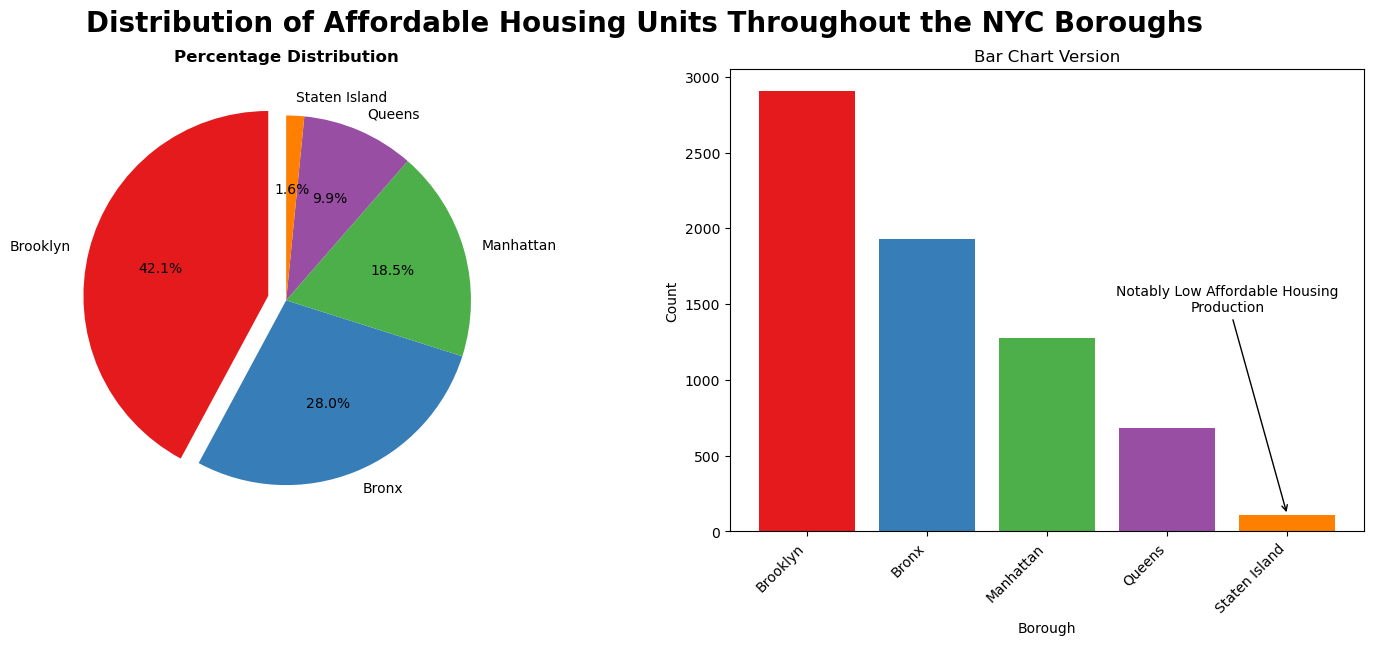

In [66]:
#create pie vs bar chart to visualize distribution of projects in each borough
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) #make subplot and set figsize pie chart left, bar chart right

#create pie chart version
axes[0].pie(borough_dist,labels=borough_dist.index, autopct='%1.1f%%', explode=[0.1, 0, 0, 0, 0], #explode Brooklyn, highest percentage
        colors=colors,startangle=90, labeldistance=1.1)
axes[0].set_title('Percentage Distribution', fontweight='bold')

#create bar chart version
axes[1].bar(borough_dist.index, borough_dist.values, color=colors)
axes[1].set_xlabel('Borough')
axes[1].set_xticklabels(borough_dist.index, rotation=45, ha='right')
axes[1].set_ylabel('Count')
axes[1].set_title('Bar Chart Version')

#annotate low unit availability in staten island
axes[1].annotate(
    'Notably Low Affordable Housing\nProduction',
    xy=(len(borough_dist)-1, borough_dist.values[-1]),   #line location
    xytext=(len(borough_dist)-1.5, max(borough_dist.values)*0.5),  #set text position 
    arrowprops=dict(facecolor='black', arrowstyle='->'), #create line
    ha='center',
    color='black',
    fontsize=10
)

fig.suptitle('Distribution of Affordable Housing Units Throughout the NYC Boroughs', fontsize=20, fontweight='bold') #bold title and change size

## Accessibility (Bedroom and AMI Distribution) - Percentage Bar Charts

In [67]:
#get total number of units for each bedroom size 
bedroom_cols = ['Studio Units', '1-BR Units', '2-BR Units', '3-BR Units', '4-BR Units',
       '5-BR Units', '6-BR+ Units']
bedroom_totals = unit_analysis[bedroom_cols].sum() #use unit_analysis df instead of main df - removed projects with over 25% unknown units 
print('Bedroom Distribution:\n', bedroom_totals)

#get total number of units for each AMI bracket
ami_cols = ['Extremely Low Income Units', 'Very Low Income Units', 'Low Income Units', 
            'Moderate Income Units','Middle Income Units', 'Other Income Units']
ami_totals = unit_analysis[ami_cols].sum() #use unit_analysis df 
print('\nAMI Distribution:\n',ami_totals)

Bedroom Distribution:
 Studio Units    41616.0
1-BR Units      84966.0
2-BR Units      84151.0
3-BR Units      31491.0
4-BR Units       2600.0
5-BR Units        140.0
6-BR+ Units        72.0
dtype: float64

AMI Distribution:
 Extremely Low Income Units    49582.0
Very Low Income Units         76013.0
Low Income Units              85242.0
Moderate Income Units         14687.0
Middle Income Units           18322.0
Other Income Units             1212.0
dtype: float64


In [68]:
bedroom_sum = bedroom_totals.sum() #calculate total of all bedroom sizes 
bedroom_percentages = (bedroom_totals / bedroom_sum) #compute proportions 
print('Bedroom Percentages\n', bedroom_percentages)

ami_sum = ami_totals.sum() #calculate total of all ami brackets
ami_percentages = (ami_totals / ami_sum) #compute proportions
print('\n AMI Percentages\n', ami_percentages)

Bedroom Percentages
 Studio Units    0.169836
1-BR Units      0.346749
2-BR Units      0.343423
3-BR Units      0.128516
4-BR Units      0.010611
5-BR Units      0.000571
6-BR+ Units     0.000294
dtype: float64

 AMI Percentages
 Extremely Low Income Units    0.202328
Very Low Income Units         0.310184
Low Income Units              0.347844
Moderate Income Units         0.059933
Middle Income Units           0.074766
Other Income Units            0.004946
dtype: float64


### Bedroom Distribution
### - Most affordable housing units are 1 bedroom (34.67%) or 2 bedroom (34.34%). 
### - Very low production of larger bedroom units: 4 bedroom (1.06%), 5 bedroom (0.06%), and 6 or more bedrooms (0.03%). This indicates a large lack of accessibility in affordable housing units for larger families. 
### 
### AMI Distribution
### - The Low Income AMI bracket has the most amount of units (34.78%), followed by Very Low Income (31.02%), and Extremely Low Income (20.23%).
### - Percentages for Middle Income (7.48%) and Moderate Income (5.99%) are considerably low, which is a good thing. This indicates that creating units in the Low Income to Extremely Low Income brackets were a priority. This supports both policy plans' goals. 
### - In my project I would like to compare their anticipated percentage breakdowns with the actual percentage breakdowns.  

C:\Users\arime\AppData\Local\Temp\ipykernel_24432\1779688887.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(bedroom_totals.index, rotation=45, ha='right')
C:\Users\arime\AppData\Local\Temp\ipykernel_24432\1779688887.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(ami_totals.index, rotation=45, ha='right')


Text(0.5, 0.98, 'Accessibility of Affordable Housing Units')

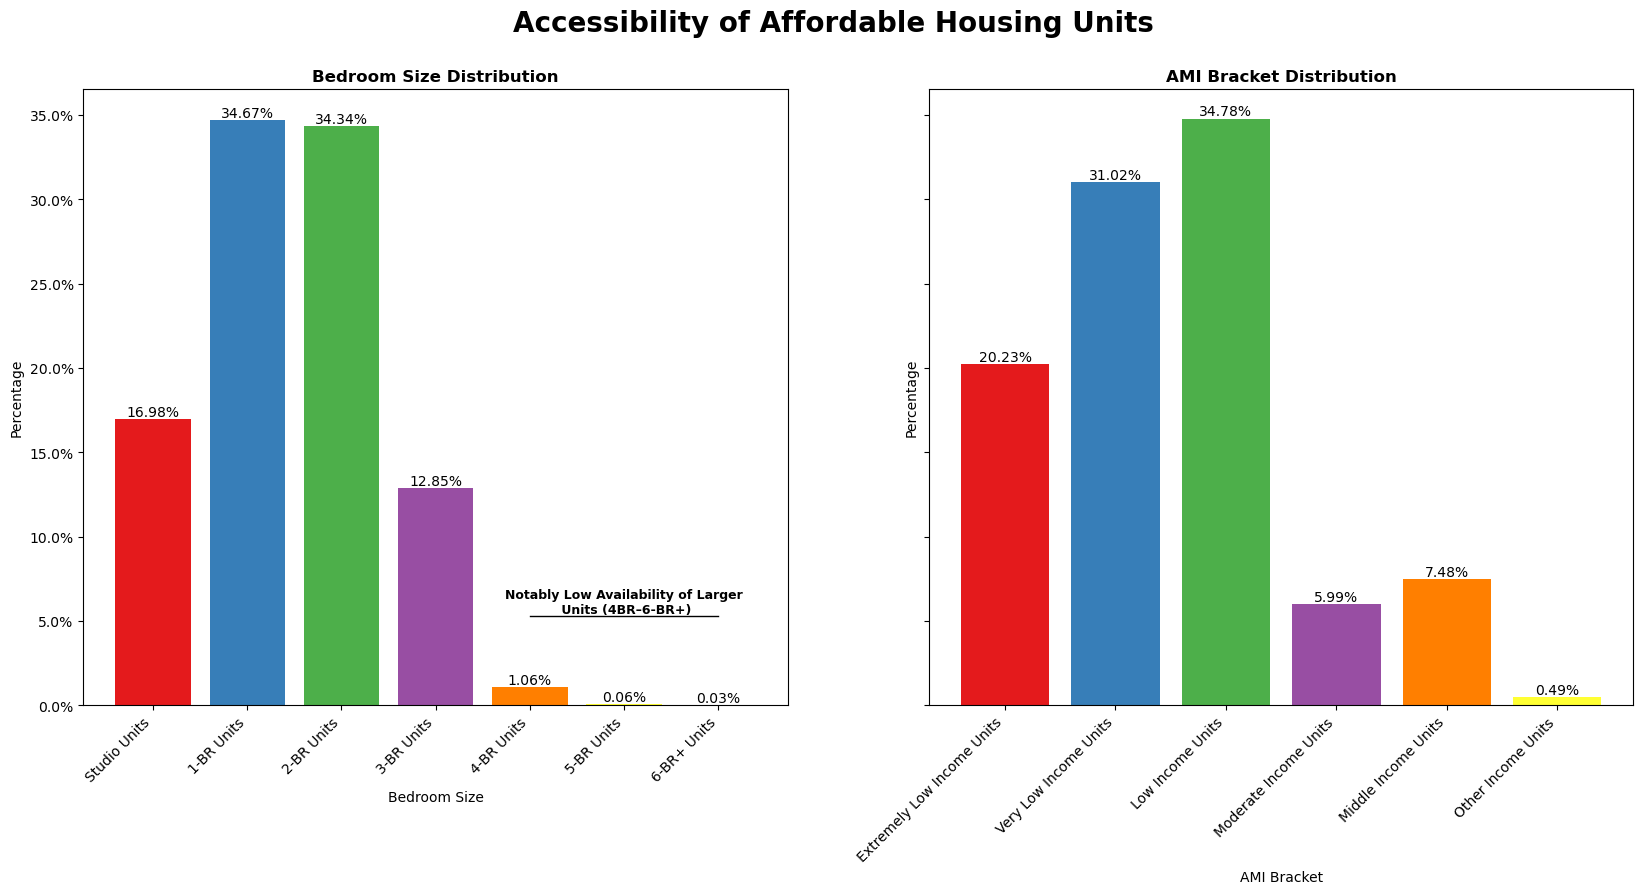

In [69]:
#bedroom distribution
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True) #bedroom figure left, ami figure right 

axes[0].bar(bedroom_totals.index, bedroom_percentages.values, color=colors)
axes[0].set_xlabel('Bedroom Size')
axes[0].set_xticklabels(bedroom_totals.index, rotation=45, ha='right')
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1)) #percentage bar chart 
axes[0].set_ylabel('Percentage')
axes[0].set_title('Bedroom Size Distribution', fontweight='bold')

#indexes of lowest bedrooms (4br, 5br, 6+br)
lowest_bedrooms = [4, 5, 6]

#get bars 
bars = axes[0].patches
xs = []
ys = []

#for loop to get positioning
for idx in lowest_bedrooms:
    bar = bars[idx]
    xs.append(bar.get_x() + bar.get_width() / 2)
    ys.append(bar.get_height())

#line positioning 
x1, x2 = xs[0], xs[-1]
y = max(ys) * 5  # height of the line (slightly above bars)

#draw line
axes[0].plot([x1, x2], [y, y], color='black', linewidth=1)

#add text
axes[0].text((x1 + x2) / 2, y * 1,
             "Notably Low Availability of Larger\n Units (4BR–6-BR+)",
             ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

#ami distribution
axes[1].bar(ami_totals.index, ami_percentages.values, color=colors)
axes[1].set_xlabel('AMI Bracket')
axes[1].set_xticklabels(ami_totals.index, rotation=45, ha='right')
axes[1].set_ylabel('Percentage')
axes[1].set_title('AMI Bracket Distribution', fontweight='bold')

#add percentage labels to bars 
for ax, data in zip(axes, [bedroom_percentages, ami_percentages]):
    for bar, pct in zip(ax.patches, data.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.2%}",
            ha='center',
            va='bottom',
            fontsize=10
        )

fig.suptitle('Accessibility of Affordable Housing Units', fontsize=20, fontweight='bold') #bold title and change size

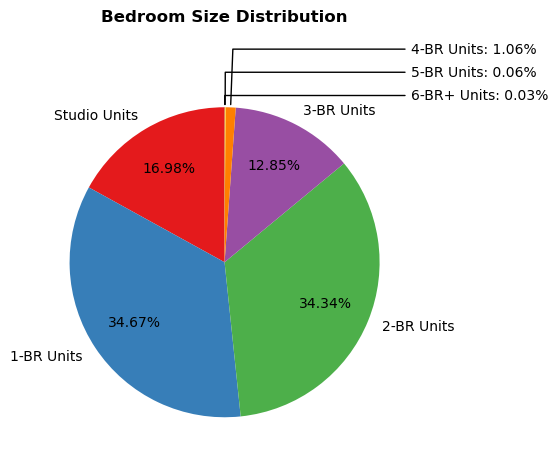

In [70]:
#pie chart version for bedroom distribution  
labels = bedroom_totals.index #bedroom sizes
sizes = bedroom_percentages.values #percentages 
low_availability = ['4-BR Units', '5-BR Units', '6-BR+ Units'] #highlight low percentages

fig, ax = plt.subplots(figsize=(5,7))

#remove labels for low_availability units 
wedges, texts = ax.pie(
    sizes,
    labels=[label if label not in low_availability else '' for label in labels],
    startangle=90,
    colors=colors
)

total = sum(sizes)

#put label and percentages for other slices 
for i, p in enumerate(wedges):
    label = labels[i]
    pct = sizes[i] / total * 100
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = 0.7 * np.sin(np.deg2rad(ang))
    x = 0.7 * np.cos(np.deg2rad(ang))
    
    if label not in low_availability:
        ax.text(x, y, f'{pct:.2f}%', ha='center', va='center', fontsize=10)

#put labels outside small slices using lines 
num_small = len(low_availability)
offsets = np.linspace(0.15, -0.15, num_small)  # spread labels evenly
offset_index = 0

for i, p in enumerate(wedges):
    label = labels[i]
    if label in low_availability:
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        pct = sizes[i] / total * 100
        text = f"{label}: {pct:.2f}%"
        
        ax.annotate(
            text,
            xy=(x, y),
            xytext=(1.2*np.sign(x), 1.2*y + offsets[offset_index]),
            horizontalalignment=horizontalalignment,
            arrowprops=dict(arrowstyle="-", connectionstyle=connectionstyle)
        )
        offset_index += 1

ax.set_title('Bedroom Size Distribution', fontweight='bold', y=1.1)

plt.show()

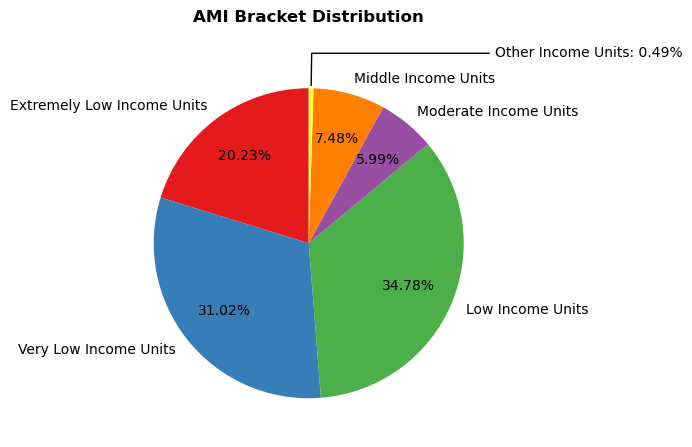

In [71]:
#pie chart version for ami bracket distribution
labels = ami_totals.index #ami brackets 
sizes = ami_percentages.values #percentages
small_slices = ['Other Income Units'] #highlight small slice 

fig, ax = plt.subplots(figsize=(5,7))

# Draw pie without autopct
wedges, texts = ax.pie(
    sizes,
    labels=[label if label not in small_slices else '' for label in labels],
    startangle=90,
    colors=colors
)

total = sum(sizes)

# Large slices: label + percentage inside
for i, p in enumerate(wedges):
    label = labels[i]
    pct = sizes[i] / total * 100
    ang = (p.theta2 + p.theta1) / 2.0
    y = 0.7 * np.sin(np.deg2rad(ang))
    x = 0.7 * np.cos(np.deg2rad(ang))
    
    if label not in small_slices:
        ax.text(x, y, f'{pct:.2f}%', ha='center', va='center', fontsize=10)

# Small slice: label + percentage outside
for i, p in enumerate(wedges):
    label = labels[i]
    if label in small_slices:
        ang = (p.theta2 + p.theta1) / 2.0
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        ha = {-1: "right", 1: "left"}[int(np.sign(x))]
        pct = sizes[i] / total * 100
        text = f"{label}: {pct:.2f}%"
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        
        ax.annotate(
            text,
            xy=(x, y),
            xytext=(1.2*np.sign(x), 1.2*y),  # further outside
            horizontalalignment=ha,
            arrowprops=dict(arrowstyle="-", connectionstyle=connectionstyle)
        )

# Raise and center title
ax.set_title('AMI Bracket Distribution', fontweight='bold', y=1.05, loc='center')

plt.show()

## Distribution of Construction Type and throughout boroughs - Bar Chart and Clustered Bar Chart

In [72]:
#get distribution of preservation vs new construction 
construction_dist = df['Reporting Construction Type'].value_counts()
print(construction_dist)

Reporting Construction Type
Preservation        3707
New Construction    3183
Name: count, dtype: int64


In [73]:
#create pivot table of construction type by borough
construction_by_borough = df.pivot_table(
    index='Borough',
    columns='Reporting Construction Type',
    values = 'Project ID',
    aggfunc='count')

print(construction_by_borough)

Reporting Construction Type  New Construction  Preservation
Borough                                                    
Bronx                                     829          1097
Brooklyn                                 1650          1254
Manhattan                                 252          1021
Queens                                    420           259
Staten Island                              32            76


### Construction Type Distribution
### - More projections were preservation projects (3707) than new construction (3183), although it is not a large difference.
### - This suggests that preservation of already constructed buildings were favored to building new ones.
###
### Construction Type by Borough
### - Despite construction type distribution, Brooklyn and Queens have more new construction than preservation. 
### - The Bronx and Staten Island both have more preservation than new construction.
### - Manhattan has notably more preservation than new construction. The biggest difference out of all five boroughs.

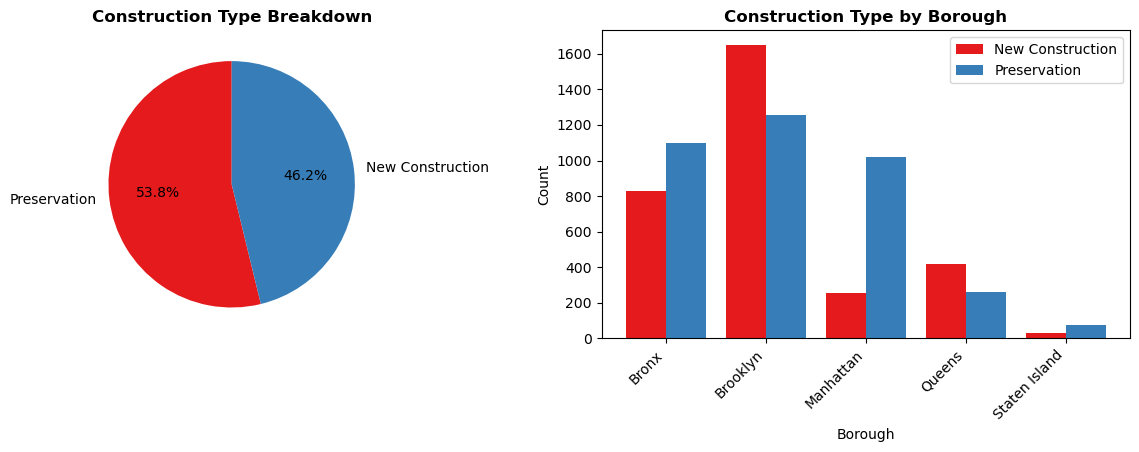

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4)) #construction dist left, borough dist right

#general distribution of preservation vs new construction
axes[0].pie(construction_dist, labels = construction_dist.index, autopct='%1.1f%%', colors=colors,
            startangle=90, labeldistance=1.1)
axes[0].set_title('Construction Type Breakdown', fontweight='bold')


#distribution of construction type by borough
cluster_borough = construction_by_borough.index
cluster_types = construction_by_borough.columns
n_boroughs = len(cluster_borough)
n_types = len(cluster_types)
bar_colors = [colors[0],colors[1]] #match colors of first graph

x = np.arange(n_boroughs)
width=0.4

for i, ctype in enumerate(cluster_types):
    axes[1].bar(x + i*width - width*(n_types-1)/2,
                construction_by_borough[ctype].values,
                width=width,
                label=ctype, 
                color=bar_colors[i])
    
axes[1].set_xticks(x)
axes[1].set_xticklabels(cluster_borough, rotation=45, ha='right')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Count')
axes[1].set_title('Construction Type by Borough', fontweight='bold')
axes[1].legend()

## Affordable Housing Production based on Administration and AMI Bracket

In [75]:
#separate units based on policy plan they are apart of
#de blasio 2014-01-01 to 2021-12-31
#adams 2022-01-01 to present 
de_blasio = (df['Project Start Date'] >= '2014-01-01') & (df['Project Start Date'] <= '2021-12-31')
adams = df['Project Start Date'] >= '2022-01-01'

de_blasio_df = df[de_blasio]
adams_df = df[adams]

de_blasio_production = de_blasio_df['Total Units'].sum() #get total units 
adams_production = adams_df['Total Units'].sum() #get total units 

In [76]:
#exclude other income and unknown income, only want to focus on known AMI brackets
filtered_ami_cols = [col for col in ami_cols if col not in ['Other Income Units','Unknown Income Units']] 

#group sums for each ami bracket by year 
ami_prod_by_year = df.groupby(df['Project Start Date'].dt.year)[filtered_ami_cols].sum() 
ami_prod_by_year

,Extremely Low Income Units,Very Low Income Units,Low Income Units,Moderate Income Units,Middle Income Units
Project Start Date,,,,,
2014,2761,2407,11716,741,1537
2015,1889,2632,9448,1679,5277
2016,4255,3524,10702,1373,2281
2017,4464,7363,9634,2105,873
2018,6516,13924,10552,996,1908
2019,5296,5965,7860,3180,2751
2020,3432,14073,8535,1082,2429
2021,4288,11434,5576,1086,4699
2022,3480,2978,4213,1001,3808


### Production by Administration
### - More affordable housing was produced under the de Blasio administration (66.9%) than the Adams administration (33.1%).
###
### Affordable Housing Production over time by AMI Bracket
### - Production across all AMI brackets experience a drop in 2022 as administration changes from de Blasio to Adams. This represents the ceasation of affordable housing production as de Blasio reached his stated goals
### - Under de Blasio administration, Extremely Low Income and Very Low Income grow considerably until about 2018 where they begin to drop. Very Low Income experiences another significant increase in 2020 (possibly in response to Covid) and then drops again.
### - Low Income Units steadily decrease throughout de Blasio's term. There is a small increase once the Adams administration starts, but production does not reach the levels it was at in the beginning of de Blasios term and then they decrease again. 
### - Interestingly, Middle Income units increase throughout de Blasio and Adams terms.
### - Production of Moderate Income units remain relatively constant throughout both administrations. 
### - Production of units across all AMI brackets drop from 2024 to 2025, this could reflect a lack of up to date data, the anticipated change in administration, or a lack of focus on production of affordable housing, or a combination of all three. 

Text(2021.9, 14611.3605, 'de Blasio → Adams')

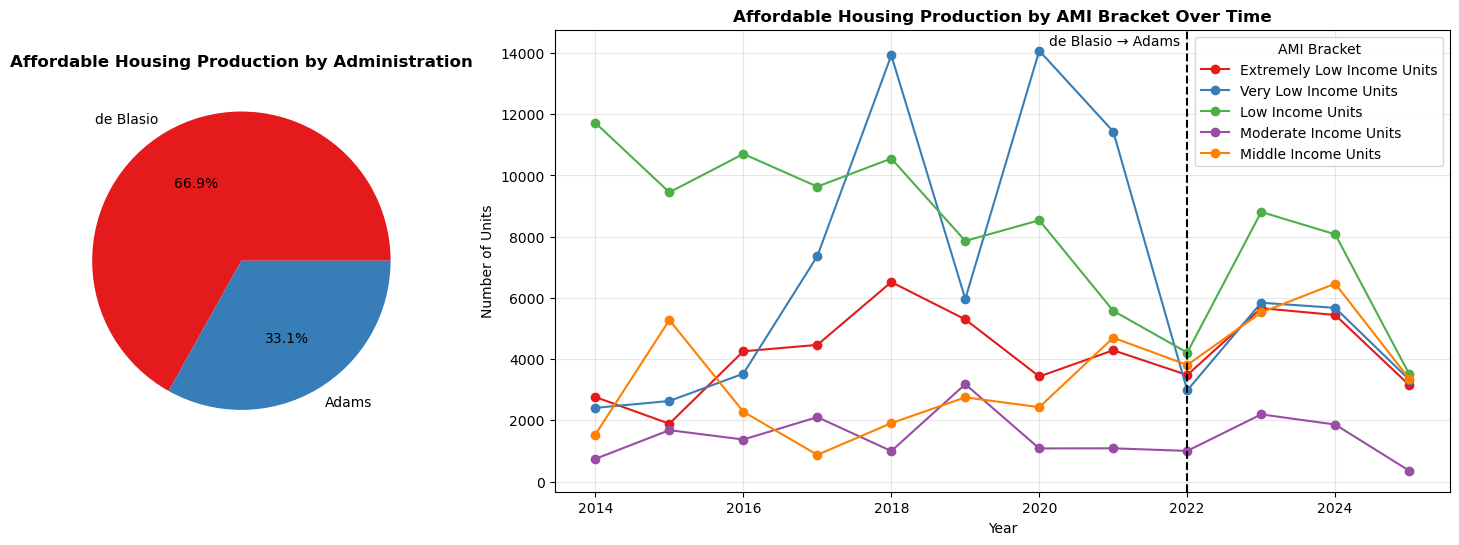

In [77]:
#admin distribution left, production by ami bracket time trend right 
fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios':[1,2.4]}) #make line graph wider

#make pie chart 
production = [de_blasio_production, adams_production]
mayor = ['de Blasio','Adams']
axes[0].pie(production,labels=mayor, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Affordable Housing Production by Administration',fontweight='bold')

#make multi-line graph
for i, col in enumerate(filtered_ami_cols):
    axes[1].plot(ami_prod_by_year.index, ami_prod_by_year[col], marker='o', label=col,
            color=colors[i])

axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Units')
axes[1].set_title('Affordable Housing Production by AMI Bracket Over Time', fontweight='bold')
axes[1].legend(title='AMI Bracket')
axes[1].grid(True, alpha=0.3)

#add vertical line to indicate change in administration from de Blasio to Adams
axes[1].axvline(x=2022, color='black', linestyle='--', linewidth=1.5)
axes[1].text(2022 - 0.1, plt.ylim()[1]*0.99, 'de Blasio → Adams', color='black', ha='right', va='top')

# Deliverable 5- Data Analysis Techniques

### (Split-Apply-Combine) - Grouping by Borough and finding averages (mean)
### Average Bedroom:
### - Averages ranged between 1.59 and 2.49, so all boroughs averages were between 1 and 3 bedroom units. 
### - Staten Island tends to have larger units with an average bedroom size of 2.49, This coincides with my knowledge of Staten Island not being directly part of the city and having more space to build bigger units/being a borough that can provide more suburban-like family living. 
### - All other boroughs had an average below 2 bedrooms. From largest to smallest: Brooklyn (1.84), Queens (1.82), Manhattan (1.64), and the Bronx (1.59). 
### - The Bronx has the smallest average bedroom size, suggesting that affordable housing in that area tends to be either studio, 1 bedroom, or 2 bedroom units. 
###
### Average AMI Bracket:
### - Averages ranged between 1.13 and 1.77 (1 is encoded as Very Low Income Units and 2 is encoded as Low Income Units), indicating that the average AMI bracket the boroughs produced housing for was either Very Low Income or Low Income. 
### - From highest to lowest: The Bronx (1.77), Brooklyn (1.64), Manhattan (1.58), Queens (1.55), and Staten Island (1.13).
### - My initial expectations was for the Bronx or Brooklyn to have the lowest AMI bracket average but they had the highest. One possible explanation I could think of for this is the trend of gentrification hitting these two boroughs in particular over the last few years. 
### 
### - In combination, I was surprised to find that Staten Island averaged the highest bedroom size while also being the borough with the lowest average AMI bracket. 
### - On the flip end, Brooklyn was found to have the lowest average bedroom size and the highest average AMI bracket.

In [78]:
#weigh bedrooms
bedroom_weights = {
    'Studio Units' : 0,
    '1-BR Units': 1,
    '2-BR Units': 2,
    '3-BR Units': 3,
    '4-BR Units': 4,
    '5-BR Units': 5,
    '6-BR+ Units': 6}

#compute weighted bedrooms
unit_analysis['Weighted_BR'] = sum(
    unit_analysis[col] * weight
    for col, weight in bedroom_weights.items())

#compute average bedroom size per row
unit_analysis['BR_Average'] = unit_analysis['Weighted_BR'] / unit_analysis['Total Units']

#average bedroom size by borough
borough_br_avg = unit_analysis.groupby('Borough')['BR_Average'].mean()
print(borough_br_avg)

Borough
Bronx            1.594341
Brooklyn         1.839620
Manhattan        1.640512
Queens           1.823762
Staten Island    2.494988
Name: BR_Average, dtype: float64


In [79]:
#weigh AMI brackets
ami_weights = {
    'Extremely Low Income Units' : 0,
    'Very Low Income Units' : 1, 
    'Low Income Units' : 2, 
    'Moderate Income Units' : 3,
    'Middle Income Units' : 4}

#compute weighted AMI brackets
unit_analysis['Weighted_AMI'] = sum(
    unit_analysis[col] * weight
    for col, weight in ami_weights.items())

#compute average ami bracket per row
unit_analysis['AMI_Average'] = unit_analysis['Weighted_AMI'] / unit_analysis['Total Units']

#average ami bracket by borough
borough_ami_avg = unit_analysis.groupby('Borough')['AMI_Average'].mean()
print(borough_ami_avg)

Borough
Bronx            1.770461
Brooklyn         1.635580
Manhattan        1.583194
Queens           1.548678
Staten Island    1.130062
Name: AMI_Average, dtype: float64


C:\Users\arime\AppData\Local\Temp\ipykernel_24432\2289141827.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(borough_br_avg.index, rotation=45, ha='right')
C:\Users\arime\AppData\Local\Temp\ipykernel_24432\2289141827.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(borough_ami_avg.index, rotation=45, ha='right')


Text(0.5, 1.0, 'Average Affordable Housing AMI Bracket by Borough')

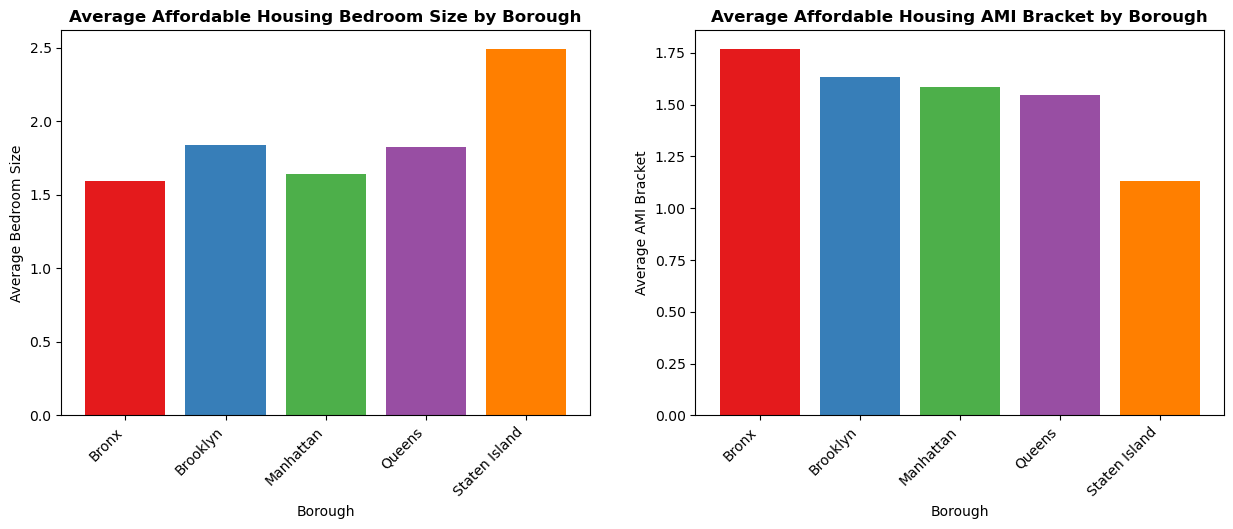

In [80]:
fig, axes = plt.subplots(1,2, figsize=(15, 5)) #bedroom left, ami right

#average bedroom size by borough
axes[0].bar(borough_br_avg.index, borough_br_avg.values, color=colors)
axes[0].set_ylabel('Average Bedroom Size')
axes[0].set_xlabel('Borough')
axes[0].set_xticklabels(borough_br_avg.index, rotation=45, ha='right')
axes[0].set_title('Average Affordable Housing Bedroom Size by Borough', fontweight='bold')

#average ami by borough
axes[1].bar(borough_ami_avg.index, borough_ami_avg.values, color=colors)
axes[1].set_ylabel('Average AMI Bracket')
axes[1].set_xlabel('Borough')
axes[1].set_xticklabels(borough_ami_avg.index, rotation=45, ha='right')
axes[1].set_title('Average Affordable Housing AMI Bracket by Borough', fontweight='bold')

### Bar chart is the visualization of the split-apply-combine I did getting averages and grouping by borough. However, I feel like the boxplots better visualize the data so I will be using that in the project. 

### (Encoding Categories): Create Administration column (0 = de Blasio, 1 = Adams)
### (Split-Apply-Combine): Compare average bedroom size and AMI, construction type, total units in each borough w/administration

In [81]:
# create new Administration column in df and unit_analysis df, de blasio, adams
df['Administration'] = np.where(
    df['Project Start Date'] < '2022-01-01',
    'De Blasio', 
    'Adams') 

unit_analysis['Administration'] = np.where(
    unit_analysis['Project Start Date'] < '2022-01-01',
    'De Blasio', 
    'Adams') 

In [82]:
#compare average AMI 
ami_admin = unit_analysis.groupby('Administration')['AMI_Average'].mean()
print(f'Average AMI Bracket:\n', ami_admin)

#compare average bedroom size 
br_admin = unit_analysis.groupby('Administration')['BR_Average'].mean()
print(f'\nAverage Bedroom Size:\n', br_admin)

Average AMI Bracket:
 Administration
Adams        1.822337
De Blasio    1.582659
Name: AMI_Average, dtype: float64

Average Bedroom Size:
 Administration
Adams        1.539600
De Blasio    1.805914
Name: BR_Average, dtype: float64


C:\Users\arime\AppData\Local\Temp\ipykernel_24432\553701817.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(ami_admin.index, rotation=45, ha='right')
C:\Users\arime\AppData\Local\Temp\ipykernel_24432\553701817.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(br_admin.index, rotation=45, ha='right')


Text(0.5, 1.0, 'Average Bedroom Size by Administration')

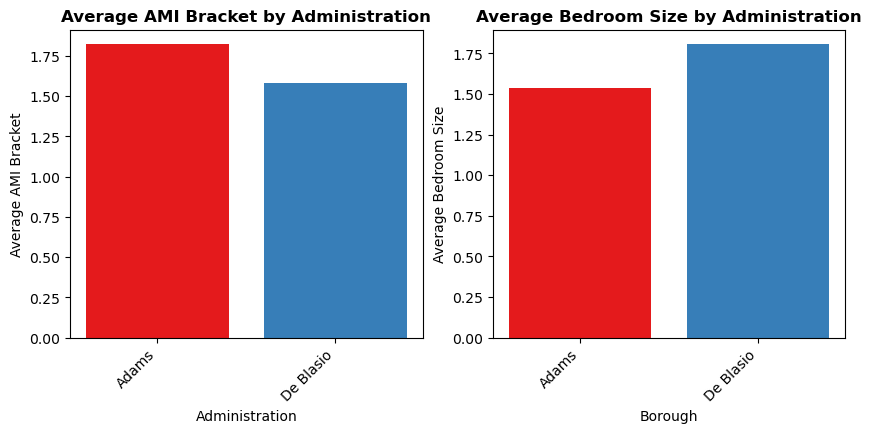

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) 

#average ami
axes[0].bar(ami_admin.index, ami_admin.values, color=colors)
axes[0].set_ylabel('Average AMI Bracket')
axes[0].set_xlabel('Administration')
axes[0].set_xticklabels(ami_admin.index, rotation=45, ha='right')
axes[0].set_title('Average AMI Bracket by Administration', fontweight='bold')


#average bedroom
axes[1].bar(br_admin.index, br_admin.values, color=colors)
axes[1].set_ylabel('Average Bedroom Size')
axes[1].set_xlabel('Borough')
axes[1].set_xticklabels(br_admin.index, rotation=45, ha='right')
axes[1].set_title('Average Bedroom Size by Administration', fontweight='bold')

C:\Users\arime\AppData\Local\Temp\ipykernel_24432\2667061152.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=unit_analysis,
C:\Users\arime\AppData\Local\Temp\ipykernel_24432\2667061152.py:4: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.boxplot(data=unit_analysis,
C:\Users\arime\AppData\Local\Temp\ipykernel_24432\2667061152.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=unit_analysis,
C:\Users\arime\AppData\Local\Temp\ipykernel_24432\2667061152.py:16: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(data=unit_analysis,


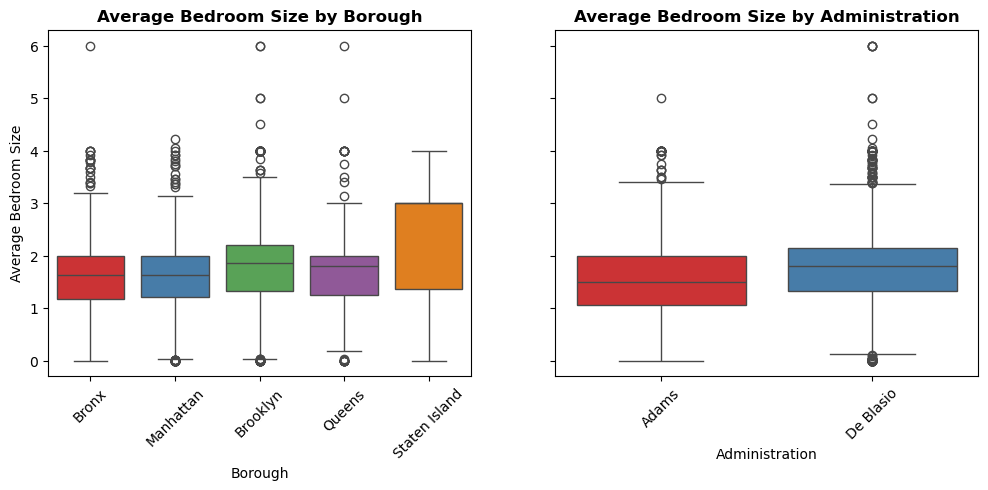

In [84]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4.5))

#plot average bedroom by borough, use seaborn for boxplots
sns.boxplot(data=unit_analysis,
    x='Borough',
    y='BR_Average',
    ax=axes[0],
    palette=colors
)
axes[0].set_title('Average Bedroom Size by Borough', fontweight='bold')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Average Bedroom Size')
axes[0].tick_params(axis='x', rotation=45)

#plot average bedroom by administration
sns.boxplot(data=unit_analysis,
    x='Administration',
    y='BR_Average',
    ax=axes[1],
    palette=colors
)
axes[1].set_title('Average Bedroom Size by Administration', fontweight='bold')
axes[1].set_xlabel('Administration')
axes[1].set_ylabel('Average Bedroom Size')
axes[1].tick_params(axis='x', rotation=45)


C:\Users\arime\AppData\Local\Temp\ipykernel_24432\3070621813.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=unit_analysis,
C:\Users\arime\AppData\Local\Temp\ipykernel_24432\3070621813.py:4: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.boxplot(data=unit_analysis,
C:\Users\arime\AppData\Local\Temp\ipykernel_24432\3070621813.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=unit_analysis,
C:\Users\arime\AppData\Local\Temp\ipykernel_24432\3070621813.py:18: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(data=unit_analysis,


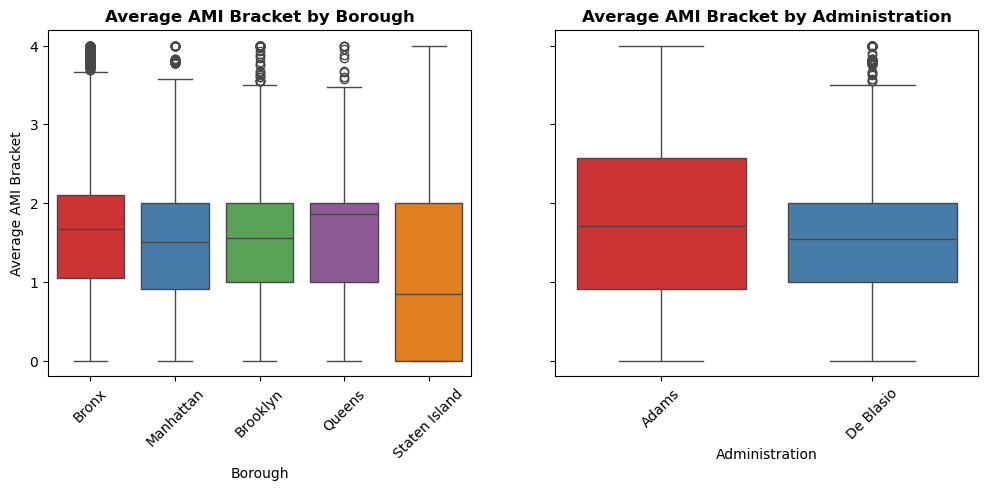

In [85]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 4.5))

#plot average ami by borough, use seaborn for boxplots
sns.boxplot(data=unit_analysis,
    x='Borough',
    y='AMI_Average',
    ax=axes[0],
    palette=colors
)
axes[0].set_title('Average AMI Bracket by Borough', fontweight='bold')
axes[0].set_xlabel('Borough')
axes[0].set_yticks(np.arange(0,5,1))
axes[0].set_ylabel('Average AMI Bracket')
axes[0].tick_params(axis='x', rotation=45)


#plot average ami administration, use seaborn for boxplots
sns.boxplot(data=unit_analysis,
    x='Administration',
    y='AMI_Average',
    ax=axes[1],
    palette=colors
)
axes[1].set_title('Average AMI Bracket by Administration', fontweight='bold')
axes[1].set_xlabel('Administration')
axes[1].set_ylabel('Average AMI Bracket')
axes[1].tick_params(axis='x', rotation=45)

In [86]:
#compare construction type, unstack to view better  
construct_admin = df.groupby(['Administration','Reporting Construction Type']).size().unstack()
print(f'Construction Type:\n', construct_admin) 

#compare housing production in each borough by mayor, unstack to view better
total_borough_admin = df.groupby(['Administration','Borough'])['Total Units'].sum().unstack()
print(f'\nTotal Unit Production:\n', total_borough_admin) 

Construction Type:
 Reporting Construction Type  New Construction  Preservation
Administration                                             
Adams                                    1387           851
De Blasio                                1796          2856

Total Unit Production:
 Borough         Bronx  Brooklyn  Manhattan  Queens  Staten Island
Administration                                                   
Adams           34368     52500      22927   21550            818
De Blasio       74607     78111      74830   35970           3554


In [87]:
df.groupby(['Administration'])['Total Units'].sum()

Administration
Adams        132163
De Blasio    267072
Name: Total Units, dtype: int64

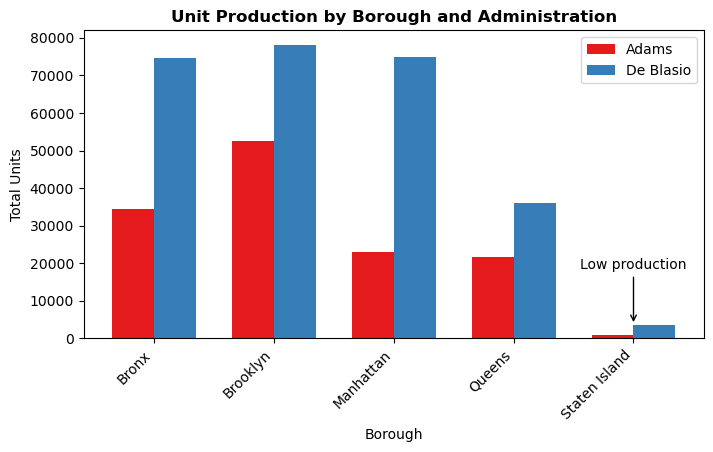

In [88]:
#clustered bar chart total projects in each borough by administration
boroughs = total_borough_admin.columns
admins = total_borough_admin.index
x = np.arange(len(boroughs))   # positions on x-axis
width = 0.35                   # width of each bar

fig, ax = plt.subplots(figsize=(8,4))

#plot clustered bars for each administration
for i, admin in enumerate(admins):
    ax.bar(x + i*width - width/2,
           total_borough_admin.loc[admin].values,
           width,
           label=admin,
           color=bar_colors[i])

#add note over staten island
#get position of staten island
staten_island = x[-1] 

#get bar height
bar_height = total_borough_admin.iloc[:, -1].max()

#add note above staten island bars 
ax.annotate('Low production',
            xy=(staten_island, bar_height),
            xytext=(staten_island, bar_height + 15000),
            arrowprops=dict(arrowstyle='->',
            connectionstyle="arc3,rad=0"),
            ha='center')

ax.set_xlabel('Borough')
ax.set_xticks(x)
ax.set_xticklabels(boroughs, rotation=45, ha='right')
ax.set_ylabel('Total Units')
ax.set_title('Unit Production by Borough and Administration', fontweight='bold')
ax.legend()